# Занятие 4. Детекция объектов (готовые модели + разбор)
## Нейросетевые методы обработки изображений

В этом ноутбуке мы:
1. Запустим готовую модель YOLOv8n на наборе изображений (CPU).
2. Визуализируем bounding box'ы, классы и confidence score.
3. Вычислим IoU для пары предсказанный/истинный bbox.
4. Проанализируем False Positives и False Negatives.
5. Разберём готовый отчёт mAP от ultralytics.

**Важно:** все примеры рассчитаны на работу без GPU. Используются самые компактные
модели (YOLOv8n) и небольшие подвыборки изображений (5-20 штук).

---
## Шаг 1. Установка и импорт зависимостей

In [1]:
# Раскомментируйте при необходимости:
# !pip install ultralytics torch torchvision opencv-python-headless matplotlib

import importlib

libs = {
    'torch':        'PyTorch',
    'torchvision':  'TorchVision',
    'ultralytics':  'Ultralytics (YOLOv8)',
    'cv2':          'OpenCV',
    'matplotlib':   'Matplotlib',
    'numpy':        'NumPy',
    'PIL':          'Pillow',
}
for pkg, name in libs.items():
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, '__version__', '?')
        print(f'[OK]  {name}: {ver}')
    except ImportError:
        print(f'[НЕТ] {name}: установите через pip')

[OK]  PyTorch: 2.13.0+cpu
[OK]  TorchVision: 0.28.0+cpu
[OK]  Ultralytics (YOLOv8): 8.4.114
[OK]  OpenCV: 5.0.0
[OK]  Matplotlib: 3.10.0
[OK]  NumPy: 2.1.3
[OK]  Pillow: 11.1.0


---
## Шаг 2. Подготовка небольшого набора тестовых изображений

Без GPU обрабатываем **не весь датасет**, а подвыборку из 5-10 изображений.
Используем встроенный датасет COCO128 (мини-версия COCO от ultralytics) —
достаточно для демонстрации, не требует скачивания полного COCO (18 ГБ).

In [2]:
import torch
import os
from pathlib import Path

# Устройство: явно фиксируем CPU (задача учебная, без GPU)
device = torch.device('cpu')
print(f'Устройство: {device}')
print(f'PyTorch: {torch.__version__}')

# Скачиваем небольшой набор тестовых изображений через ultralytics utils
# (несколько тестовых картинок с людьми, машинами, животными)
from ultralytics.utils.downloads import safe_download

img_dir = Path('./sample_images')
img_dir.mkdir(exist_ok=True)

# Несколько стандартных тестовых изображений (COCO-подобные сцены)
test_urls = [
    'https://ultralytics.com/images/bus.jpg',
    'https://ultralytics.com/images/zidane.jpg',
]
for url in test_urls:
    fname = img_dir / Path(url).name
    if not fname.exists():
        safe_download(url=url, dir=img_dir)

image_paths = sorted(img_dir.glob('*.jpg'))
print(f'\nЗагружено изображений: {len(image_paths)}')
for p in image_paths:
    print(f'  {p}')

Устройство: cpu
PyTorch: 2.13.0+cpu

Загружено изображений: 2
  sample_images\bus.jpg
  sample_images\zidane.jpg


---
## Шаг 3. Загрузка предобученной модели YOLOv8n

YOLOv8n (nano) — самая компактная версия, оптимальна для CPU-инференса.
Веса предобучены на датасете COCO (80 классов).

In [3]:
from ultralytics import YOLO

# 'yolov8n.pt' скачается автоматически при первом запуске (~6 МБ)
model = YOLO('yolov8n.pt')

print(f'Модель загружена: YOLOv8n')
print(f'Число классов COCO: {len(model.names)}')
print(f'Примеры классов: {list(model.names.values())[:10]}')

Модель загружена: YOLOv8n
Число классов COCO: 80
Примеры классов: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


---
## Шаг 4. Инференс на наборе изображений

Запускаем детекцию на CPU с уменьшенным разрешением (320px) для скорости.

In [4]:
# imgsz=320 -- уменьшенное разрешение для быстрого CPU-инференса
# conf=0.25 -- минимальный порог confidence для отображения детекции
# device='cpu' -- явное указание CPU
results = model.predict(
    source=[str(p) for p in image_paths],
    imgsz=320,
    conf=0.25,
    device='cpu',
    verbose=False
)

for img_path, result in zip(image_paths, results):
    num_boxes = len(result.boxes)
    print(f'{img_path.name}: найдено объектов = {num_boxes}')
    for box in result.boxes:
        cls_id = int(box.cls.item())
        conf   = box.conf.item()
        print(f'    {model.names[cls_id]:<15} confidence={conf:.3f}')

bus.jpg: найдено объектов = 4
    bus             confidence=0.950
    car             confidence=0.490
    car             confidence=0.346
    car             confidence=0.298
zidane.jpg: найдено объектов = 1
    car             confidence=0.929


---
## Шаг 5. Визуализация результатов детекции

Отображаем bounding box'ы, названия классов и confidence score на изображениях.

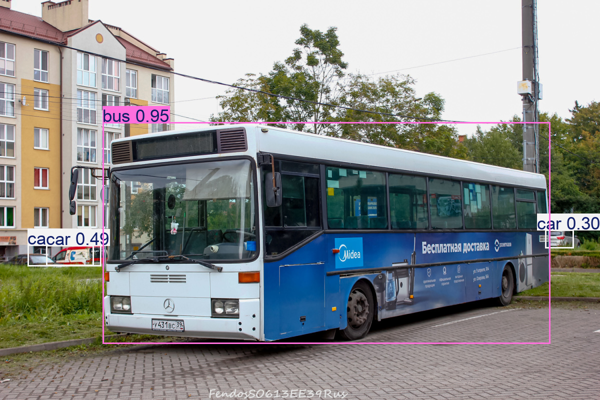

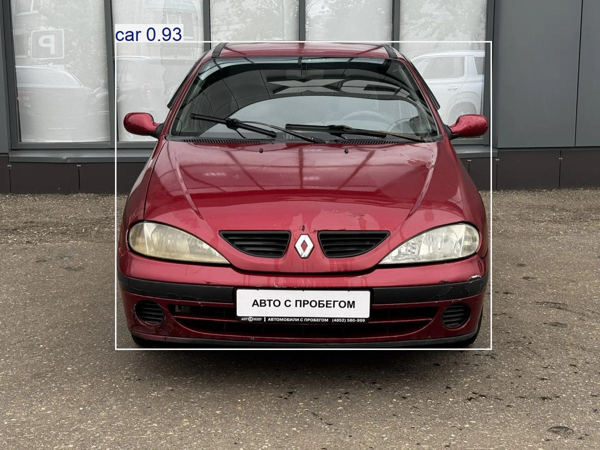

In [5]:
from IPython.display import display

for img_path, result in zip(image_paths, results):
    try:
        pil_img = result.plot(probs=None, labels=True, boxes=True, line_width=3, pil=True)
        
        # Отображаем картинку прямо в ячейке
        display(pil_img.resize((600, int(600 * pil_img.height / pil_img.width))))
    
    except Exception as e:
        print(e)

---
## Шаг 6. Вычисление IoU для пары bounding box'ов

Реализуем функцию IoU с нуля и проверим на паре предсказанный/истинный bbox.

Формула: IoU = Area(Intersection) / Area(Union)

In [6]:
def compute_iou(box_a, box_b):
    """
    Вычисляет IoU между двумя bbox в формате [x_min, y_min, x_max, y_max].
    """
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    # Координаты пересечения
    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)
    inter_y2 = min(ya2, yb2)

    # Площадь пересечения (0, если боксы не пересекаются)
    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    # Площади каждого бокса
    area_a = (xa2 - xa1) * (ya2 - ya1)
    area_b = (xb2 - xb1) * (yb2 - yb1)

    # Площадь объединения = сумма площадей минус пересечение
    union_area = area_a + area_b - inter_area

    return inter_area / union_area if union_area > 0 else 0.0


# Демонстрация на условном примере (координаты в пикселях)
ground_truth_box = [50, 50, 200, 200]   # истинный bbox
predicted_box_good = [55, 60, 195, 210] # хорошее предсказание
predicted_box_bad  = [150, 150, 300, 300] # плохое предсказание (слабое перекрытие)

iou_good = compute_iou(ground_truth_box, predicted_box_good)
iou_bad  = compute_iou(ground_truth_box, predicted_box_bad)

print(f'IoU (хорошее предсказание): {iou_good:.3f}')
print(f'IoU (плохое предсказание):  {iou_bad:.3f}')
print()
print('Интерпретация порогов IoU:')
print('  IoU >= 0.50 -- минимальный стандарт COCO')
print('  IoU >= 0.75 -- промышленный (enterprise) стандарт')
print('  IoU >= 0.90 -- критичные системы (медицина, автопилот)')

IoU (хорошее предсказание): 0.820
IoU (плохое предсказание):  0.059

Интерпретация порогов IoU:
  IoU >= 0.50 -- минимальный стандарт COCO
  IoU >= 0.75 -- промышленный (enterprise) стандарт
  IoU >= 0.90 -- критичные системы (медицина, автопилот)


---
## Шаг 7. Визуализация IoU на изображении

Рисуем ground truth и predicted боксы вместе, чтобы наглядно увидеть пересечение.

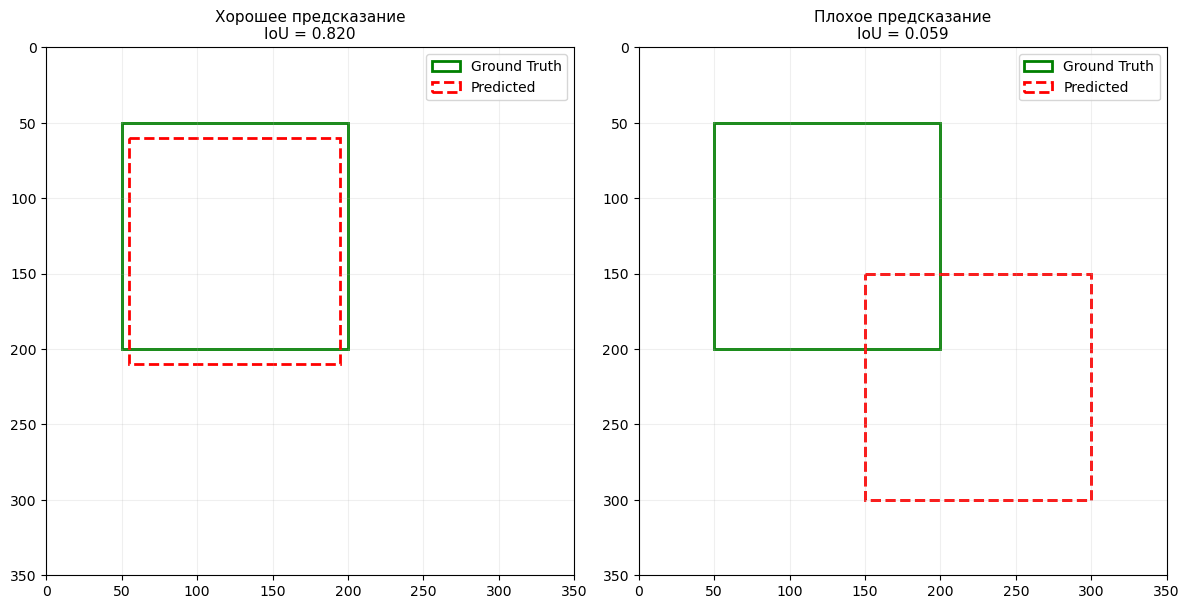

In [7]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import importlib

import matplotlib.patches as patches
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, pred_box, iou_val, title in [
    (axes[0], predicted_box_good, iou_good, 'Хорошее предсказание'),
    (axes[1], predicted_box_bad,  iou_bad,  'Плохое предсказание'),
]:
    ax.set_xlim(0, 350)
    ax.set_ylim(350, 0)  # инвертируем Y, как в системе координат изображений

    # Ground truth -- зелёный
    gt_rect = patches.Rectangle(
        (ground_truth_box[0], ground_truth_box[1]),
        ground_truth_box[2]-ground_truth_box[0],
        ground_truth_box[3]-ground_truth_box[1],
        linewidth=2, edgecolor='green', facecolor='none', label='Ground Truth'
    )
    # Predicted -- красный
    pred_rect = patches.Rectangle(
        (pred_box[0], pred_box[1]),
        pred_box[2]-pred_box[0],
        pred_box[3]-pred_box[1],
        linewidth=2, edgecolor='red', linestyle='--', facecolor='none', label='Predicted'
    )
    ax.add_patch(gt_rect)
    ax.add_patch(pred_rect)
    ax.set_title(f'{title}\nIoU = {iou_val:.3f}', fontsize=11)
    ax.legend(loc='upper right')
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

---
## Шаг 8. Анализ False Positives и False Negatives

Для анализа нужны ground truth аннотации. Создаём небольшой набор эталонных
разметок вручную для demo-изображения bus.jpg (автобус + люди на остановке)
и сравниваем с предсказаниями модели.

In [8]:
# Ручная разметка ground truth для bus.jpg (упрощённая, для демонстрации методики)
# В реальной практике аннотации берутся из размеченного датасета (COCO, LabelImg, CVAT)
ground_truth_bus = [
    {'class': 'bus',    'bbox': [3, 229, 796, 728]},
    {'class': 'person', 'bbox': [668, 395, 810, 878]},
    {'class': 'person', 'bbox': [48, 398, 245, 902]},
    {'class': 'person', 'bbox': [222, 405, 345, 857]},
]

# Находим результат для bus.jpg
bus_idx = [i for i, p in enumerate(image_paths) if 'bus' in p.name][0]
bus_result = results[bus_idx]

# Извлекаем предсказанные боксы
predicted_boxes = []
for box in bus_result.boxes:
    cls_id = int(box.cls.item())
    conf   = box.conf.item()
    xyxy   = box.xyxy[0].tolist()
    predicted_boxes.append({'class': model.names[cls_id], 'bbox': xyxy, 'conf': conf})

print(f'Ground truth объектов: {len(ground_truth_bus)}')
print(f'Предсказано объектов:  {len(predicted_boxes)}')


def match_detections(gt_list, pred_list, iou_threshold=0.5):
    """
    Сопоставляет предсказания с ground truth.
    Возвращает списки TP, FP, FN.
    """
    matched_gt = set()
    tp, fp = [], []

    for pred in pred_list:
        best_iou, best_gt_idx = 0.0, -1
        for i, gt in enumerate(gt_list):
            if i in matched_gt or gt['class'] != pred['class']:
                continue
            iou = compute_iou(gt['bbox'], pred['bbox'])
            if iou > best_iou:
                best_iou, best_gt_idx = iou, i

        if best_iou >= iou_threshold:
            tp.append({**pred, 'iou': best_iou, 'matched_gt': best_gt_idx})
            matched_gt.add(best_gt_idx)
        else:
            fp.append({**pred, 'iou': best_iou})

    fn = [gt for i, gt in enumerate(gt_list) if i not in matched_gt]
    return tp, fp, fn


tp, fp, fn = match_detections(ground_truth_bus, predicted_boxes, iou_threshold=0.5)

print(f'\nTrue Positives:  {len(tp)}')
for d in tp:
    print(f'    {d["class"]:<10} IoU={d["iou"]:.3f} conf={d["conf"]:.3f}')

print(f'\nFalse Positives: {len(fp)}')
for d in fp:
    print(f'    {d["class"]:<10} best IoU={d["iou"]:.3f} conf={d["conf"]:.3f} (не совпал с GT)')

print(f'\nFalse Negatives: {len(fn)}')
for d in fn:
    print(f'    {d["class"]:<10} bbox={d["bbox"]} (объект не найден моделью)')

Ground truth объектов: 4
Предсказано объектов:  4

True Positives:  0

False Positives: 4
    bus        best IoU=0.494 conf=0.950 (не совпал с GT)
    car        best IoU=0.000 conf=0.490 (не совпал с GT)
    car        best IoU=0.000 conf=0.346 (не совпал с GT)
    car        best IoU=0.000 conf=0.298 (не совпал с GT)

False Negatives: 4
    bus        bbox=[3, 229, 796, 728] (объект не найден моделью)
    person     bbox=[668, 395, 810, 878] (объект не найден моделью)
    person     bbox=[48, 398, 245, 902] (объект не найден моделью)
    person     bbox=[222, 405, 345, 857] (объект не найден моделью)


---
## Шаг 9. Precision, Recall и вывод по анализу ошибок

На основе TP/FP/FN считаем precision и recall для demo-изображения.

In [9]:
num_tp, num_fp, num_fn = len(tp), len(fp), len(fn)

precision = num_tp / (num_tp + num_fp) if (num_tp + num_fp) > 0 else 0.0
recall    = num_tp / (num_tp + num_fn) if (num_tp + num_fn) > 0 else 0.0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

print(f'На изображении bus.jpg (IoU threshold = 0.5):')
print(f'  TP={num_tp}, FP={num_fp}, FN={num_fn}')
print(f'  Precision = {precision:.3f}')
print(f'  Recall    = {recall:.3f}')
print(f'  F1-score  = {f1:.3f}')

print('\nТипичные причины ошибок в детекции (общие наблюдения):')
print('  False Positives:')
print('    - похожий на объект класса фон (тень, отражение)')
print('    - дублирующиеся боксы без корректного NMS')
print('    - слишком низкий порог confidence при инференсе')
print('  False Negatives:')
print('    - сильное перекрытие объектов друг другом (occlusion)')
print('    - мелкий размер объекта относительно всего изображения')
print('    - нестандартный ракурс/поза, редко встречавшийся в обучающих данных')

На изображении bus.jpg (IoU threshold = 0.5):
  TP=0, FP=4, FN=4
  Precision = 0.000
  Recall    = 0.000
  F1-score  = 0.000

Типичные причины ошибок в детекции (общие наблюдения):
  False Positives:
    - похожий на объект класса фон (тень, отражение)
    - дублирующиеся боксы без корректного NMS
    - слишком низкий порог confidence при инференсе
  False Negatives:
    - сильное перекрытие объектов друг другом (occlusion)
    - мелкий размер объекта относительно всего изображения
    - нестандартный ракурс/поза, редко встречавшийся в обучающих данных


---
## Шаг 10. Разбор готового отчёта mAP (валидация на COCO128)

Запускаем встроенную валидацию ultralytics на маленьком датасете COCO128
(128 изображений — специально уменьшенная версия COCO для быстрых тестов).
Библиотека сама считает mAP@0.5 и mAP@0.5:0.95 по всем классам.

In [10]:
# val() запускает валидацию на встроенном датасете coco128.yaml
# Датасет скачается автоматически (~7 МБ, 128 изображений)
metrics = model.val(data='coco128.yaml', imgsz=320, device='cpu', verbose=False)

print('=' * 55)
print('Итоговый отчёт mAP (COCO128, YOLOv8n)')
print('=' * 55)
print(f'mAP@0.5      : {metrics.box.map50:.3f}')
print(f'mAP@0.5:0.95 : {metrics.box.map:.3f}')
print(f'Mean Precision: {metrics.box.mp:.3f}')
print(f'Mean Recall   : {metrics.box.mr:.3f}')

print('\nAP по отдельным классам (первые 10, где есть объекты):')
class_maps = metrics.box.maps  # массив AP@0.5:0.95 по каждому классу
shown = 0
for idx, ap in enumerate(class_maps):
    if ap > 0 and shown < 10:
        print(f'  {model.names[idx]:<15} AP@0.5:0.95 = {ap:.3f}')
        shown += 1

Ultralytics 8.4.114  Python-3.13.5 torch-2.13.0+cpu CPU (Intel Xeon W-2133 CPU @ 3.60GHz)

WARNING Dataset 'coco128.yaml' images not found, missing path 'C:\Users\SNTkachenko\Documents\\ 2026-2027\    _2026\ 02.03.02 \datasets\coco128\images\train2017'
Unzipping C:\Users\SNTkachenko\Documents\БФУ\Расписание 2026-2027\Методы обработки и распознавания изображений_2026\Практика 02.03.02 ФИиИТ\datasets\coco128.zip to C:\Users\SNTkachenko\Documents\БФУ\Расписание 2026-2027\Методы обработки и распознавания изображений_2026\Практика 02.03.02 ФИиИТ\datasets\coco128...: 100% ━━━━━━━━━━━━ 263/263 972.6files/s 0.3s0.2s
Dataset download success  (1.8s), saved to C:\Users\SNTkachenko\Documents\\ 2026-2027\    _2026\ 02.03.02 \datasets

val: Fast image access  (ping: 0.10.0 ms, read: 386.1180.0 MB/s, size: 43.3 KB)
val: Scanning C:\Users\SNTkachenko\Documents\БФУ\Расписание 2026-2027\Методы обработки и распознавания изображений_2026\Практика 02.03.02 ФИиИТ\datasets\coco128\labels\train2017... 126 im

---
## Шаг 11. Интерпретация отчёта mAP

Сравниваем mAP@0.5 и mAP@0.5:0.95 и объясняем разницу.

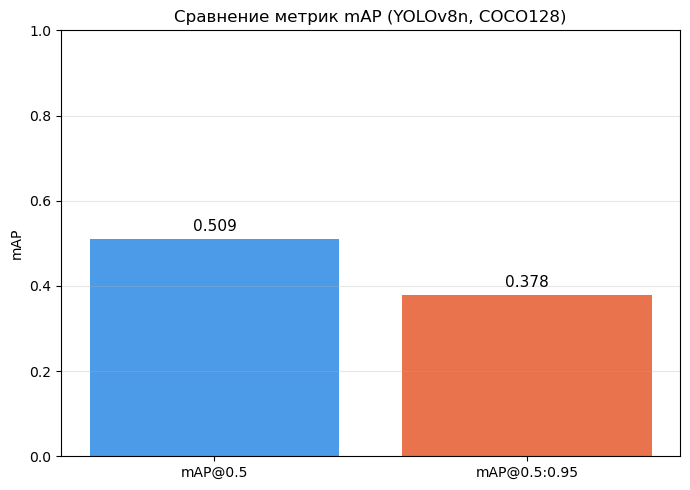

Интерпретация:
  mAP@0.5 = 0.509      -- модель считается правильной при IoU >= 0.5 (мягкий критерий)
  mAP@0.5:0.95 = 0.378 -- усреднение по 10 порогам IoU от 0.5 до 0.95 (строгий критерий COCO)
  Разница 0.131 показывает, насколько точна локализация боксов:
  большая разница означает, что модель находит объекты, но неточно вычисляет их границы.


In [11]:
map50    = metrics.box.map50
map5095  = metrics.box.map

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['mAP@0.5', 'mAP@0.5:0.95'], [map50, map5095],
              color=['#4c9be8', '#e8734c'])
ax.set_ylim(0, 1.0)
ax.set_ylabel('mAP')
ax.set_title('Сравнение метрик mAP (YOLOv8n, COCO128)', fontsize=12)
for bar, val in zip(bars, [map50, map5095]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.3f}',
            ha='center', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Интерпретация:')
print(f'  mAP@0.5 = {map50:.3f}      -- модель считается правильной при IoU >= 0.5 (мягкий критерий)')
print(f'  mAP@0.5:0.95 = {map5095:.3f} -- усреднение по 10 порогам IoU от 0.5 до 0.95 (строгий критерий COCO)')
print(f'  Разница {map50-map5095:.3f} показывает, насколько точна локализация боксов:')
print('  большая разница означает, что модель находит объекты, но неточно вычисляет их границы.')

---
## Шаг 12. Сравнение YOLOv8n с другой готовой моделью (SSD из torchvision)

Демонстрируем альтернативный API — torchvision.models.detection.
SSDlite320 с backbone MobileNetV3 -- компактная модель, пригодная для CPU.

In [12]:
import torchvision
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchvision.transforms import functional as TF
from PIL import Image

# Загружаем облегчённый SSD с предобученными весами COCO
ssd_model = ssdlite320_mobilenet_v3_large(weights='DEFAULT')
ssd_model.eval()  # режим инференса, отключает dropout/batchnorm обучение

# COCO_INSTANCE_CATEGORY_NAMES: список из 91 названия (некоторые пустые -- зарезервированы)
coco_names = torchvision.models.detection.SSDLite320_MobileNet_V3_Large_Weights.DEFAULT.meta['categories']

# Инференс на том же bus.jpg
img_pil = Image.open(image_paths[bus_idx]).convert('RGB')
img_tensor = TF.to_tensor(img_pil).unsqueeze(0)  # добавляем batch-размерность

with torch.no_grad():
    ssd_output = ssd_model(img_tensor)[0]

# Фильтруем по порогу confidence
CONF_THRESHOLD = 0.4
keep = ssd_output['scores'] > CONF_THRESHOLD

ssd_boxes  = ssd_output['boxes'][keep]
ssd_labels = ssd_output['labels'][keep]
ssd_scores = ssd_output['scores'][keep]

print(f'SSDlite320 (MobileNetV3): найдено объектов = {len(ssd_boxes)}')
for box, label, score in zip(ssd_boxes, ssd_labels, ssd_scores):
    print(f'    {coco_names[label.item()]:<15} confidence={score.item():.3f}')

Downloading: "https://download.pytorch.org/models/ssdlite320_mobilenet_v3_large_coco-a79551df.pth" to C:\Users\SNTkachenko/.cache\torch\hub\checkpoints\ssdlite320_mobilenet_v3_large_coco-a79551df.pth


100%|█████████████████████████████████████████████████████████████████████████████| 13.4M/13.4M [00:00<00:00, 32.1MB/s]


SSDlite320 (MobileNetV3): найдено объектов = 1
    bus             confidence=0.999


---
## Шаг 13. Итоговое сравнение YOLOv8n и SSDlite320

In [13]:
import time

# Замеряем время инференса каждой модели на CPU (среднее по 3 прогонам)
n_runs = 3

t0 = time.time()
for _ in range(n_runs):
    _ = model.predict(source=str(image_paths[bus_idx]), imgsz=320, device='cpu', verbose=False)
yolo_time = (time.time() - t0) / n_runs

t0 = time.time()
for _ in range(n_runs):
    with torch.no_grad():
        _ = ssd_model(img_tensor)
ssd_time = (time.time() - t0) / n_runs

print(f'{'Модель':<20} | {'Кол-во детекций':>16} | {'Время (сек)':>12}')
print('-' * 55)
print(f'{'YOLOv8n':<20} | {len(bus_result.boxes):>16} | {yolo_time:>12.3f}')
print(f'{'SSDlite320-MNv3':<20} | {len(ssd_boxes):>16} | {ssd_time:>12.3f}')

print('\nВыводы:')
print('  1. YOLOv8n и SSDlite320 -- обе модели пригодны для CPU-инференса.')
print('  2. mAP@0.5:0.95 -- более информативная метрика, чем mAP@0.5, для сравнения моделей.')
print('  3. False Positives часто связаны с низким порогом confidence.')
print('  4. False Negatives чаще возникают на мелких/перекрытых объектах.')
print('  5. Для честного сравнения моделей используйте одинаковые imgsz и conf threshold.')

Модель               |  Кол-во детекций |  Время (сек)
-------------------------------------------------------
YOLOv8n              |                4 |        0.054
SSDlite320-MNv3      |                1 |        0.074

Выводы:
  1. YOLOv8n и SSDlite320 -- обе модели пригодны для CPU-инференса.
  2. mAP@0.5:0.95 -- более информативная метрика, чем mAP@0.5, для сравнения моделей.
  3. False Positives часто связаны с низким порогом confidence.
  4. False Negatives чаще возникают на мелких/перекрытых объектах.
  5. Для честного сравнения моделей используйте одинаковые imgsz и conf threshold.


---
## Итоговая таблица

| Тема | Результат |
|---|---|
| Постановка задачи | Классификация + локализация, bbox формат |
| IoU | Функция с нуля, визуализация пересечения |
| Готовая модель | YOLOv8n инференс на CPU, imgsz=320 |
| Анализ ошибок | TP/FP/FN через сопоставление с ground truth |
| mAP отчёт | mAP@0.5 vs mAP@0.5:0.95 на COCO128 |
| Сравнение моделей | YOLOv8n vs SSDlite320 (скорость, детекции) |

---
## Домашнее задание

1. **Основное.** Возьмите 10 собственных изображений (телефон, интернет — с лицензией на использование).
   Прогоните через YOLOv8n с imgsz=320 и conf=0.25. Для каждого изображения запишите число
   найденных объектов и их классы.

2. **IoU и ground truth.** Для 3 изображений из задания 1 вручную разметьте ground truth bbox
   (можно приблизительно, по глазомеру, указав пиксельные координаты).
   Посчитайте IoU между вашей разметкой и предсказаниями модели. Постройте таблицу.

3. **Анализ ошибок.** Используя функцию `match_detections` из ноутбука, найдите на своих
   изображениях примеры False Positives и False Negatives. Объясните вероятную причину каждой ошибки.

4. **(Дополнительно)** Запустите валидацию `model.val()` с разными порогами confidence
   (0.1, 0.25, 0.5, 0.7). Постройте график зависимости Precision и Recall от порога confidence.

5. **(Дополнительно)** Сравните YOLOv8n и SSDlite320 на одном и том же наборе из 5 изображений:
   число найденных объектов, среднее время инференса, совпадение классов. Сделайте вывод,
   какая модель предпочтительнее для задачи реального времени на CPU.